In [2]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score # Common metric for link prediction
import matplotlib.pyplot as plt

import os
import numpy as np
import json

from utils.hake_dataset import invert_nested_dict

/home/mai/miniconda3/envs/pyg-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch_geometric import seed_everything

seed_everything(4444)

In [4]:
DATA_PATH = './data'

# folder to save entity id mapping
ID_MAPPING = os.path.join(DATA_PATH, 'entity_id_map')
os.makedirs(ID_MAPPING, exist_ok=True)

# folder to save edge index
EDGE_INDEX = os.path.join(DATA_PATH, 'edge_index')
os.makedirs(EDGE_INDEX, exist_ok=True)

# folder to save graph data
GRAPH_DATA = os.path.join(DATA_PATH, 'graph_data')
os.makedirs(GRAPH_DATA, exist_ok=True)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
# load data
data = torch.load(os.path.join(GRAPH_DATA, 'yfinance_kge_full.pt'))

# Load the map (assuming invert_nested_dict is defined)
with open(os.path.join(ID_MAPPING, 'global_id.json')) as f:
    raw_global2local = invert_nested_dict(json.load(f)) # Use a temporary name

# 2. Convert ALL keys and values to integers (CRITICAL STEP)
global2local = {}
for ntype, g_to_l_map in raw_global2local.items():
    # Convert global ID keys (strings) and local ID values (strings) to integers
    global2local[ntype] = {
        int(global_id): int(local_id) 
        for global_id, local_id in g_to_l_map.items()
    }

EDGE_TYPES_ORIGINAL = [
    ('company', 'has_symbol', 'stock_symbol'),
    ('company', 'belongs_to', 'industry'),
    ('industry', 'is_part_of', 'sector'),
    ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
    ('fund', 'has_symbol', 'fund_symbol'),
]

FINAL_EDGE_TYPES = []
device = data.edge_index_dict[EDGE_TYPES_ORIGINAL[0]].device # Get device from an existing tensor

print("Starting localization of edge indices and creating inverse relations...")

for src, rel, dst in EDGE_TYPES_ORIGINAL:
    
    original_edge_type = (src, rel, dst)
    
    # 1. Check and Retrieve Data
    if original_edge_type not in data.edge_types:
        print(f"Warning: Skipping {original_edge_type} - not found in data.")
        continue
        
    # Get the original index tensor (assumed to hold global IDs).
    # Move to CPU for efficient dictionary lookup, then back to device later.
    original_index_global = data[original_edge_type].edge_index.cpu() 
    
    # Get the mapping dictionaries for source and destination types
    src_map = global2local[src]
    dst_map = global2local[dst]

    # Create lists to hold the new, localized indices
    new_src_indices = []
    new_dst_indices = []
    
    # Map the global IDs to local IDs
    for i in range(original_index_global.size(1)):
        global_src_id = original_index_global[0, i].item()
        global_dst_id = original_index_global[1, i].item()
        
        try:
            # Look up the new local IDs using the nested map structure
            new_src_indices.append(src_map[global_src_id])
            new_dst_indices.append(dst_map[global_dst_id])
        except KeyError as e:
            # This handles cases where an edge points to a node ID that 
            # might not be present in your loaded features/map (e.g., filtered nodes).
            # We skip the problematic edge.
            # print(f"KeyError: Missing Global ID {e} in map for edge type {original_edge_type}. Skipping edge.")
            continue


    # 2. Overwrite the Original Edge with the localized index
    new_index_local = torch.stack([
        torch.tensor(new_src_indices, dtype=torch.long),
        torch.tensor(new_dst_indices, dtype=torch.long)
    ]).to(device)

    data[original_edge_type].edge_index = new_index_local
    FINAL_EDGE_TYPES.append(original_edge_type)

    
    # 3. Create the Inverse Edge
    inverse_rel = f'rev_{rel}'
    inverse_edge_type = (dst, inverse_rel, src)
    
    # The inverse index is the new_index_local flipped!
    data[inverse_edge_type].edge_index = new_index_local.flip(0)
    FINAL_EDGE_TYPES.append(inverse_edge_type)
    
print(f"✅ Localization complete. Total edge types (Original + Inverse): {len(FINAL_EDGE_TYPES)}")

/tmp/ipykernel_4036/884776007.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(GRAPH_DATA, 'yfinance_kge_full.pt'))


Starting localization of edge indices and creating inverse relations...
✅ Localization complete. Total edge types (Original + Inverse): 12


In [7]:
data

HeteroData(
  company={ x=[4164, 70] },
  fund_symbol={ x=[6340, 61] },
  sector={ x=[13, 39] },
  industry={ x=[146, 41] },
  stock_symbol={ x=[4607, 32] },
  institution={ x=[2669, 32] },
  fund={ x=[2222, 32] },
  (company, has_symbol, stock_symbol)={ edge_index=[2, 4508] },
  (company, belongs_to, industry)={ edge_index=[2, 3992] },
  (industry, is_part_of, sector)={ edge_index=[2, 144] },
  (institution, holds, stock_symbol)={ edge_index=[2, 39512] },
  (fund, holds, stock_symbol)={ edge_index=[2, 37098] },
  (fund, has_symbol, fund_symbol)={ edge_index=[2, 6851] },
  (stock_symbol, rev_has_symbol, company)={ edge_index=[2, 4508] },
  (industry, rev_belongs_to, company)={ edge_index=[2, 3992] },
  (sector, rev_is_part_of, industry)={ edge_index=[2, 144] },
  (stock_symbol, rev_holds, institution)={ edge_index=[2, 39512] },
  (stock_symbol, rev_holds, fund)={ edge_index=[2, 37098] },
  (fund_symbol, rev_has_symbol, fund)={ edge_index=[2, 6851] }
)

# 1. Define GNN Encoder

In [8]:
class GNNEncoder(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        # Use -1 for input dimensions to enable 'lazy initialization'
        # PyG will automatically determine the feature size for each node type
        self.conv1 = SAGEConv((-1, -1), out_channels)
        # self.conv2 = SAGEConv((-1, -1), out_channels)
        self.act = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.act(x)
        x = self.dropout(x)
        # x = self.conv2(x, edge_index)
        return x

# 2. Define Link predictor (decoder)

In [9]:
class EdgeDecoder(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, z_src, z_dst, edge_label_index):
        # Retrieve the embeddings for the edges' source and destination nodes
        src, dst = edge_label_index
        z_src = z_src[src]
        z_dst = z_dst[dst]
        
        # Calculate the score (e.g., dot product)
        score = torch.sum(z_src * z_dst, dim=-1)
        return score

# 3. Training & eval functions

In [10]:
def split_data(data, num_val, num_test, neg_sampling_ratio, is_undirected, edge_types, rev_edge_types):
    transform = RandomLinkSplit(
        num_val=num_val,
        num_test=num_test,
        neg_sampling_ratio=neg_sampling_ratio,
        is_undirected=is_undirected,
        edge_types=edge_types,
        rev_edge_types=rev_edge_types,
    )
    train_data, val_data, test_data = transform(data)
    return train_data, val_data, test_data

In [11]:
def train(data, hetero_model, predictor, optimizer, edge_types, criterion):
    """Performs a single training epoch"""
    hetero_model.train()
    predictor.train()
    optimizer.zero_grad()
    # Link Prediction and Loss Calculation
    z = hetero_model(data.x_dict, data.edge_index_dict)
    total_loss = 0
    
    # Iterate over all target edge types
    for edge_type in edge_types:
        # Retrieve ALL samples for the current edge type
        edge_label_index = data[edge_type].edge_label_index
        edge_labels = data[edge_type].edge_label.float() # Targets (0s and 1s)

        # Calculate scores (raw logits) for all sampled edges
        scores = predictor(z[edge_type[0]], z[edge_type[-1]], edge_label_index)

        # Calculate BCEWithLogitsLoss
        loss = criterion(scores, edge_labels)
        
        total_loss += loss
        
    # 3. Backpropagate (Ensure you have gradient clipping here if needed!)
    total_loss.backward()
    
    optimizer.step()
    
    return total_loss.item()

In [12]:
# evaluation function

@torch.no_grad()
def evaluate(data, hetero_model, predictor, edge_types, criterion):
    """Evaluates the model and returns the total loss and AUC score"""
    hetero_model.eval()
    predictor.eval()

    z = hetero_model(data.x_dict, data.edge_index_dict)

    total_loss = 0
    all_scores = []
    all_labels = []

    for edge_type in edge_types:
        edge_label_index = data[edge_type].edge_label_index
        edge_labels = data[edge_type].edge_label.float() # Targets (0s and 1s)

        # Calculate raw scores (logits)
        scores_logits = predictor(z[edge_type[0]], z[edge_type[-1]], edge_label_index)
        
        # Calculate loss using raw logits
        loss = criterion(scores_logits, edge_labels)
        total_loss += loss.item()
        
        # Convert logits to probabilities (0-1) for AUC calculation
        scores_prob = torch.sigmoid(scores_logits)
        
        # Collect probabilities and labels for AUC
        all_scores.append(scores_prob.cpu())
        all_labels.append(edge_labels.cpu())

    # Calculate overall AUC
    try:
        y_score = torch.cat(all_scores).view(-1).numpy()
        y_true = torch.cat(all_labels).view(-1).numpy()
        
        # AUC check for positive samples
        auc = roc_auc_score(y_true, y_score) if len(torch.unique(torch.tensor(y_true))) > 1 else 0.5
    except ValueError:
        auc = 0.5

    return total_loss, auc

In [20]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, val_aucs):
    """
    Plots the training loss, validation loss, and validation AUC over epochs.

    Args:
        train_losses (list): List of training loss values per epoch.
        val_losses (list): List of validation loss values per epoch.
        val_aucs (list): List of validation AUC scores per epoch.
    """
    
    # Calculate the number of epochs from the length of the logged lists
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # --- Plot 1: Loss Curve (Train vs. Validation) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', linestyle='-')
    plt.plot(epochs, val_losses, label='Validation Loss', linestyle='--')
    
    plt.title('Loss Curve Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True, alpha=0.5)

    # --- Plot 2: AUC Curve (Validation Metric) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_aucs, label='Train AUC', ls='-')
    plt.plot(epochs, val_aucs, label='Validation AUC', ls='-')
    
    plt.title('AUC Score')
    plt.xlabel('Epoch')
    plt.ylabel('AUC Score')
    plt.ylim(0.0, 1.0) # AUC scores are between 0 and 1
    plt.legend()
    plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

# 4. Execution

In [48]:
EPOCHS = 5000
# HIDDEN_CHANNELS = 256
OUT_CHANNELS = 32
LEARNING_RATE = 0.0001

NODE_TYPES = ['company', 'stock_symbol', 'industry', 'sector', 
              'institution', 'fund', 'fund_symbol']

FEATURE_DIMS = {ntype: data[ntype].x.shape[1] for ntype in NODE_TYPES}

## 4.1. Link prediction between funds and stock symbols

In [49]:
EDGE_TYPES = [
    # ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    # ('stock_symbol', 'rev_holds', 'institution'),
    ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [50]:
# data split
data = data.to(device)

train_data, val_data, test_data = split_data(data, 
                                             num_val=0.2, 
                                             num_test=0.2, 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=EDGE_TYPES,
                                             rev_edge_types=REV_EDGE_TYPES,
                                            )

In [51]:
# model intialization
model = GNNEncoder(OUT_CHANNELS)
hetero_model = to_hetero(model, data.metadata(), aggr='sum').to(device)
predictor = EdgeDecoder().to(device)

optimizer = torch.optim.Adam(
        list(hetero_model.parameters()) + list(predictor.parameters()), lr=LEARNING_RATE
)

In [52]:
# training loop
train_losses = []
train_aucs = []
val_losses = []
val_aucs = []

criterion = torch.nn.BCEWithLogitsLoss()
print("\nStarting training loop...")
for epoch in range(1, EPOCHS + 1):
    # Call the single-epoch train function
    train_loss = train(train_data, hetero_model, predictor, optimizer, EDGE_TYPES, criterion)
    
    # Call the evaluation function for validation
    _, train_auc = evaluate(train_data, hetero_model, predictor, EDGE_TYPES, criterion)
    val_loss, val_auc = evaluate(val_data, hetero_model, predictor, EDGE_TYPES, criterion)

    # Log metrics
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:02d}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

# --- 3.5. Final Testing and Plotting ---
test_loss, test_auc = evaluate(test_data, hetero_model, predictor, EDGE_TYPES, criterion)
print(f"\n✅ Training Complete. Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")


Starting training loop...
Epoch: 10/5000, Train Loss: 1.3023, Train AUC: 0.5394, Val Loss: 1.1721, Val AUC: 0.5419
Epoch: 20/5000, Train Loss: 1.2499, Train AUC: 0.5423, Val Loss: 1.1438, Val AUC: 0.5442
Epoch: 30/5000, Train Loss: 1.2191, Train AUC: 0.5451, Val Loss: 1.1169, Val AUC: 0.5466
Epoch: 40/5000, Train Loss: 1.1949, Train AUC: 0.5480, Val Loss: 1.0916, Val AUC: 0.5490
Epoch: 50/5000, Train Loss: 1.1666, Train AUC: 0.5506, Val Loss: 1.0678, Val AUC: 0.5512
Epoch: 60/5000, Train Loss: 1.1472, Train AUC: 0.5531, Val Loss: 1.0453, Val AUC: 0.5532
Epoch: 70/5000, Train Loss: 1.1208, Train AUC: 0.5555, Val Loss: 1.0241, Val AUC: 0.5552
Epoch: 80/5000, Train Loss: 1.1068, Train AUC: 0.5579, Val Loss: 1.0043, Val AUC: 0.5572
Epoch: 90/5000, Train Loss: 1.0857, Train AUC: 0.5603, Val Loss: 0.9856, Val AUC: 0.5591
Epoch: 100/5000, Train Loss: 1.0628, Train AUC: 0.5627, Val Loss: 0.9681, Val AUC: 0.5610
Epoch: 110/5000, Train Loss: 1.0285, Train AUC: 0.5651, Val Loss: 0.9515, Val AUC:

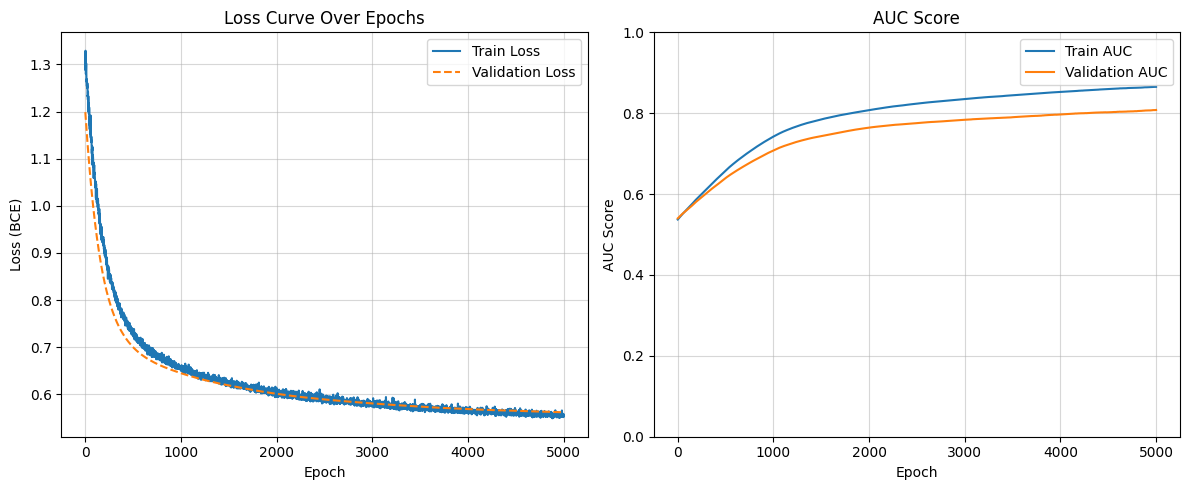

In [53]:
# Call the function here:
plot_metrics(train_losses, val_losses, val_aucs)

## 4.2. Link prediction between institutions and stock symbols

In [54]:
EDGE_TYPES = [
    ('institution', 'holds', 'stock_symbol'),
    # ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    ('stock_symbol', 'rev_holds', 'institution'),
    # ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [55]:
# data split
data = data.to(device)

train_data, val_data, test_data = split_data(data, 
                                             num_val=0.2, 
                                             num_test=0.2, 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=EDGE_TYPES,
                                             rev_edge_types=REV_EDGE_TYPES,
                                            )

In [56]:
# model intialization
model = GNNEncoder(OUT_CHANNELS)
hetero_model = to_hetero(model, data.metadata(), aggr='sum').to(device)
predictor = EdgeDecoder().to(device)

optimizer = torch.optim.Adam(
        list(hetero_model.parameters()) + list(predictor.parameters()), lr=LEARNING_RATE
)

In [57]:
# training loop
train_losses = []
train_aucs = []
val_losses = []
val_aucs = []

criterion = torch.nn.BCEWithLogitsLoss()
print("\nStarting training loop...")
for epoch in range(1, EPOCHS + 1):
    # Call the single-epoch train function
    train_loss = train(train_data, hetero_model, predictor, optimizer, EDGE_TYPES, criterion)
    
    # Call the evaluation function for validation
    _, train_auc = evaluate(train_data, hetero_model, predictor, EDGE_TYPES, criterion)
    val_loss, val_auc = evaluate(val_data, hetero_model, predictor, EDGE_TYPES, criterion)

    # Log metrics
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:02d}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

# --- 3.5. Final Testing and Plotting ---
test_loss, test_auc = evaluate(test_data, hetero_model, predictor, EDGE_TYPES, criterion)
print(f"\n✅ Training Complete. Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")


Starting training loop...
Epoch: 10/5000, Train Loss: 1.0365, Train AUC: 0.4158, Val Loss: 0.9432, Val AUC: 0.4261
Epoch: 20/5000, Train Loss: 0.9975, Train AUC: 0.4190, Val Loss: 0.9298, Val AUC: 0.4292
Epoch: 30/5000, Train Loss: 0.9875, Train AUC: 0.4221, Val Loss: 0.9170, Val AUC: 0.4321
Epoch: 40/5000, Train Loss: 0.9739, Train AUC: 0.4253, Val Loss: 0.9050, Val AUC: 0.4352
Epoch: 50/5000, Train Loss: 0.9680, Train AUC: 0.4284, Val Loss: 0.8935, Val AUC: 0.4382
Epoch: 60/5000, Train Loss: 0.9502, Train AUC: 0.4315, Val Loss: 0.8827, Val AUC: 0.4411
Epoch: 70/5000, Train Loss: 0.9343, Train AUC: 0.4347, Val Loss: 0.8725, Val AUC: 0.4441
Epoch: 80/5000, Train Loss: 0.9196, Train AUC: 0.4378, Val Loss: 0.8629, Val AUC: 0.4470
Epoch: 90/5000, Train Loss: 0.9187, Train AUC: 0.4408, Val Loss: 0.8538, Val AUC: 0.4499
Epoch: 100/5000, Train Loss: 0.9019, Train AUC: 0.4439, Val Loss: 0.8452, Val AUC: 0.4527
Epoch: 110/5000, Train Loss: 0.8868, Train AUC: 0.4469, Val Loss: 0.8371, Val AUC:

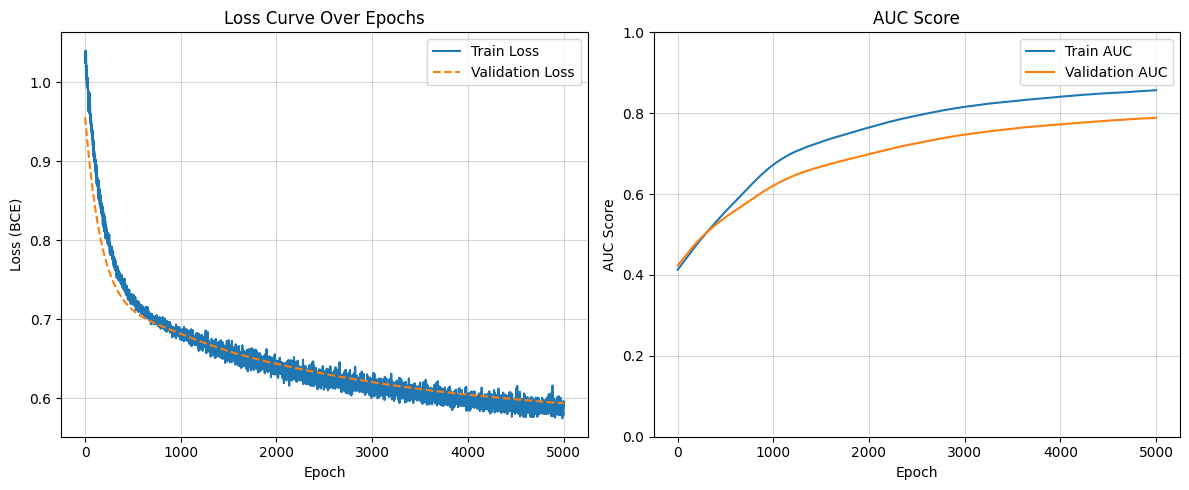

In [58]:
# Call the function here:
plot_metrics(train_losses, val_losses, val_aucs)